**This program is a heart disease predictor. It is designed to predict whether a patient has heart disease or not based on various health parameters. The program uses various machine learning algorithms to make predictions based on the input data, and it also provides the accuracy of each model used for prediction and decides to use the best presice and accurate models from:**
---

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. K-Nearest Neighbors Classifier
5. Support Vector Classifier
6. Gaussian Naive Bayes
7. XGBoost Classifier

**Importing libraries**

In [374]:
print("Importing libraries...")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.metrics as skm
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
print("Importing libraries completed.")

Importing libraries...
Importing libraries completed.


**Importing models**

In [375]:
print("Importing models...")
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
print("Importing models completed.")

Importing models...
Importing models completed.


**Importing data**

In [376]:
print("Importing data...")
data = pd.read_csv("heart.csv")
print("Data imported successfully.")

Importing data...
Data imported successfully.


**here are the following steps to follow to make the best possible machine learning model**
* **Step 1**: Exploratory Data Analysis
* **Step 2**: Deciding what to take as input and what to spit as output
* **Step 3**: Preparing and arranging dataset for models to proccess
* **Step 4**: Scale the dataset
* **Step 5**: Train test split
* **Step 6**: Train the models
* **Step 7**: Record and display results
* **Step 8**: Select the best performing model

**Step 1**: Exploratory Data Analysis

In [377]:
print(data.head(5))
print(data.info())
print(data.describe())
print("no of columns: ", len(data.columns))
print("no of rows: ", len(data))

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs    

**Step 2**: Deciding what to take as input and what to spit as output

In [378]:
print("here are the columns:", data.columns)
print("target output is:", data.columns[-1])
print("input features are:", data.columns[:-1])
print("all values are integers except for the target output which is boolean/categorical.")

here are the columns: Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')
target output is: target
input features are: Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='str')
all values are integers except for the target output which is boolean/categorical.


**Step 3**: Preparing and arranging dataset for models to proccess

In [379]:
prsdata = data.copy()
print(prsdata.shape)
print(prsdata.columns)
print("all columns are ordered correctly.")

(1025, 14)
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')
all columns are ordered correctly.


**Step 4**: Scale the dataset

In [380]:
data = data.dropna()
prsdata = prsdata.dropna()
print("missing values of data dropped, new shape is:", data.shape)
print("missing values of prsdata dropped, new shape is:", prsdata.shape)

scaler = StandardScaler()
prsdata[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']] = scaler.fit_transform(prsdata[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']])
print("data scaled, new shape is:", prsdata.shape)

# Crucial Fix: added dtype=int to prevent True/False booleans from breaking XGBoost
data = pd.get_dummies(data, columns=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'], drop_first=True, dtype=int)
print("data one-hot encoded, new shape is:", data.shape)
prsdata = pd.get_dummies(prsdata, columns=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'], drop_first=True, dtype=int)
print("data one-hot encoded, new shape is:", prsdata.shape)

leprsd = LabelEncoder()
led = LabelEncoder()
data["target"] = led.fit_transform(data["target"])
prsdata["target"] = leprsd.fit_transform(prsdata["target"])
print("target variable mapped, new shape is:", prsdata.shape)

print("first 5 rows of prsdata:")
print(prsdata.head(5))
print("first 5 rows of data:")
print(data.head(5))


missing values of data dropped, new shape is: (1025, 14)
missing values of prsdata dropped, new shape is: (1025, 14)
data scaled, new shape is: (1025, 14)
data one-hot encoded, new shape is: (1025, 23)
data one-hot encoded, new shape is: (1025, 23)
target variable mapped, new shape is: (1025, 23)
first 5 rows of prsdata:
        age  trestbps      chol   thalach   oldpeak  target  sex_1  cp_1  \
0 -0.268437 -0.377636 -0.659332  0.821321 -0.060888       0      1     0   
1 -0.158157  0.479107 -0.833861  0.255968  1.727137       0      1     0   
2  1.716595  0.764688 -1.396233 -1.048692  1.301417       0      1     0   
3  0.724079  0.936037 -0.833861  0.516900 -0.912329       0      1     0   
4  0.834359  0.364875  0.930822 -1.874977  0.705408       0      0     0   

   cp_2  cp_3  ...  exang_1  slope_1  slope_2  ca_1  ca_2  ca_3  ca_4  thal_1  \
0     0     0  ...        0        0        1     0     1     0     0       0   
1     0     0  ...        1        0        0     0     0 

**Here is all list of all the ML algorithms we will train:**

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. K-Nearest Neighbors Classifier
5. Support Vector Classifier
6. Gaussian Naive Bayes
7. XGBoost Classifier 

**Step 5**: Train test split

In [381]:
data_train, data_test = train_test_split(data, test_size=0.2, random_state=42)
print("training rows : ", len(data_train))
print("testing rows  : ", len(data_test))
X_train = data_train.drop("target", axis=1)
y_train = data_train["target"]
X_test = data_test.drop("target", axis=1)
y_test = data_test["target"]

prs_data_train, prs_data_test = train_test_split(prsdata, test_size=0.2, random_state=42)
print("training rows : ", len(prs_data_train))
print("testing rows  : ", len(prs_data_test))
prs_X_train = prs_data_train.drop("target", axis=1)
prs_y_train = prs_data_train["target"]
prs_X_test = prs_data_test.drop("target", axis=1)
prs_y_test = prs_data_test["target"]

training rows :  820
testing rows  :  205
training rows :  820
testing rows  :  205


**Step 6**: Train the models

1.Logistic reggresion model

In [382]:
LogReg = LogisticRegression()
LogReg.fit(prs_X_train, prs_y_train)
y_pred_logreg = LogReg.predict(prs_X_test)

2. Decision Tree Classifier

In [383]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

3. Random Forest Classifier

In [384]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
y_pred_rfc = rfc.predict(X_test)

4. K-Nearest Neighbors Classifier

In [385]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(prs_X_train, prs_y_train)
y_pred_knn = knn.predict(prs_X_test)

5. Support Vector Classifier

In [386]:
svm = SVC()
svm.fit(prs_X_train, prs_y_train)
y_pred_svm = svm.predict(prs_X_test)

6. Gaussian Naive Bayes

In [387]:
gnb = GaussianNB()
gnb.fit(prs_X_train, prs_y_train)
y_pred_gnb = gnb.predict(prs_X_test)

7. XGBoost Classifier 

In [388]:
xgb=xgb.XGBClassifier()
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

**Step 7**: Record and display results

In [389]:
print("""All models have been trained and predictions have been made to show the performance of the model, we will print the classification report and confusion matrix.""")

print("Logistic Regression Classification Report:")
print(skm.classification_report(y_test, y_pred_logreg))
print("Logistic Regression Confusion Matrix:")
print(skm.confusion_matrix(y_test, y_pred_logreg))

print("Decision Tree Classification Report:")
print(skm.classification_report(y_test, y_pred_dt))
print("Decision Tree Confusion Matrix:")
print(skm.confusion_matrix(y_test, y_pred_dt))

print("Random Forest Classification Report:")
print(skm.classification_report(y_test, y_pred_rfc))
print("Random Forest Confusion Matrix:")
print(skm.confusion_matrix(y_test, y_pred_rfc))

print("K-Nearest Neighbors Classification Report:")
print(skm.classification_report(y_test, y_pred_knn))
print("K-Nearest Neighbors Confusion Matrix:")
print(skm.confusion_matrix(y_test, y_pred_knn))

print("Support Vector Machine Classification Report:")
print(skm.classification_report(y_test, y_pred_svm))
print("Support Vector Machine Confusion Matrix:")
print(skm.confusion_matrix(y_test, y_pred_svm))

print("Gaussian Naive Bayes Classification Report:")
print(skm.classification_report(y_test, y_pred_gnb))
print("Gaussian Naive Bayes Confusion Matrix:")
print(skm.confusion_matrix(y_test, y_pred_gnb))

print("XGboost Classification Report:")
print(skm.classification_report(y_test, y_pred_xgb))
print("XGboost Confusion Matrix:")
print(skm.confusion_matrix(y_test, y_pred_xgb))

All models have been trained and predictions have been made to show the performance of the model, we will print the classification report and confusion matrix.
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.75      0.80       102
           1       0.78      0.89      0.83       103

    accuracy                           0.82       205
   macro avg       0.83      0.82      0.82       205
weighted avg       0.83      0.82      0.82       205

Logistic Regression Confusion Matrix:
[[76 26]
 [11 92]]
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       102
           1       1.00      1.00      1.00       103

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

Decision Tree Confusion Matrix:
[[102   0]
 [  0 

**Visualisation:**

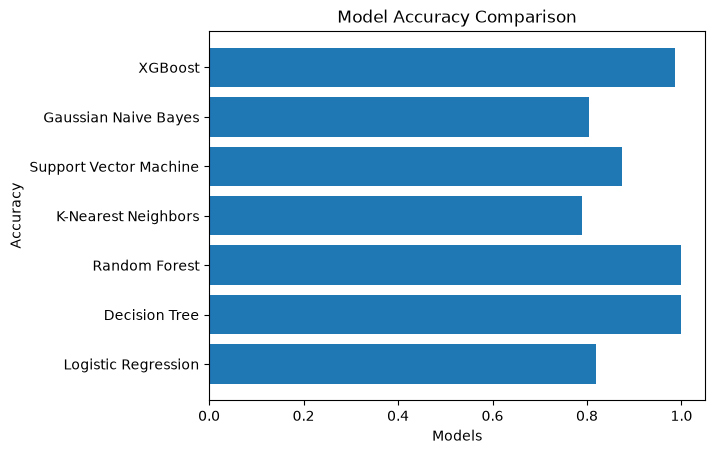

In [390]:
acc = [skm.accuracy_score(y_test, y_pred_logreg), skm.accuracy_score(y_test, y_pred_dt), skm.accuracy_score(y_test, y_pred_rfc), skm.accuracy_score(y_test, y_pred_knn), skm.accuracy_score(y_test, y_pred_svm), skm.accuracy_score(y_test, y_pred_gnb), skm.accuracy_score(y_test, y_pred_xgb)]
mdl_n = ["Logistic Regression", "Decision Tree", "Random Forest", "K-Nearest Neighbors", "Support Vector Machine", "Gaussian Naive Bayes", "XGBoost"]
plt.barh(mdl_n, acc)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

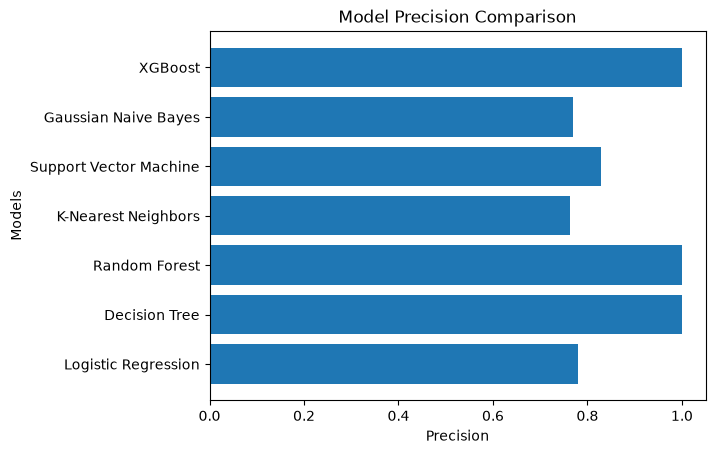

In [391]:
precision = [skm.precision_score(y_test, y_pred_logreg), skm.precision_score(y_test, y_pred_dt), skm.precision_score(y_test, y_pred_rfc), skm.precision_score(y_test, y_pred_knn), skm.precision_score(y_test, y_pred_svm), skm.precision_score(y_test, y_pred_gnb), skm.precision_score(y_test, y_pred_xgb)]
plt.barh(mdl_n, precision)
plt.xlabel("Precision")
plt.ylabel("Models")
plt.title("Model Precision Comparison")
plt.show()

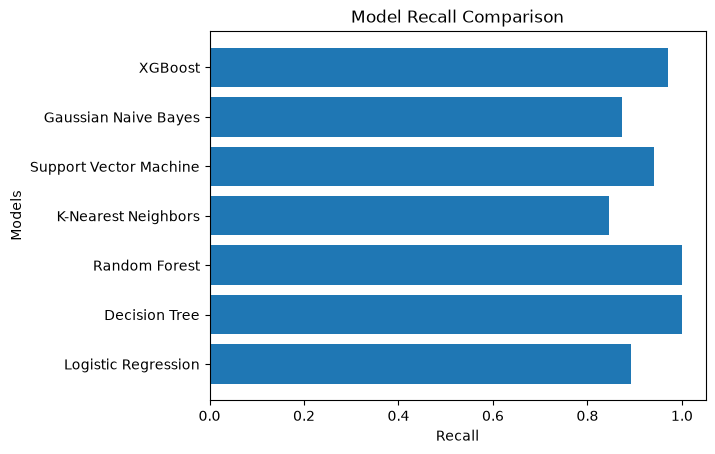

In [392]:
recall=[skm.recall_score(y_test, y_pred_logreg), skm.recall_score(y_test, y_pred_dt), skm.recall_score(y_test, y_pred_rfc), skm.recall_score(y_test, y_pred_knn), skm.recall_score(y_test, y_pred_svm), skm.recall_score(y_test, y_pred_gnb), skm.recall_score(y_test, y_pred_xgb)]
plt.barh(mdl_n, recall)
plt.xlabel("Recall")
plt.ylabel("Models")
plt.title("Model Recall Comparison")
plt.show()

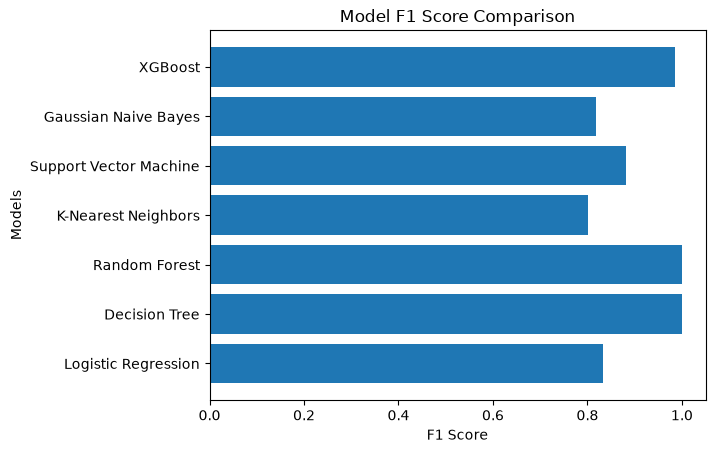

In [393]:
f1=[skm.f1_score(y_test, y_pred_logreg), skm.f1_score(y_test, y_pred_dt), skm.f1_score(y_test, y_pred_rfc), skm.f1_score(y_test, y_pred_knn), skm.f1_score(y_test, y_pred_svm), skm.f1_score(y_test, y_pred_gnb), skm.f1_score(y_test, y_pred_xgb)]
plt.barh(mdl_n, f1)
plt.xlabel("F1 Score")
plt.ylabel("Models")
plt.title("Model F1 Score Comparison")
plt.show()

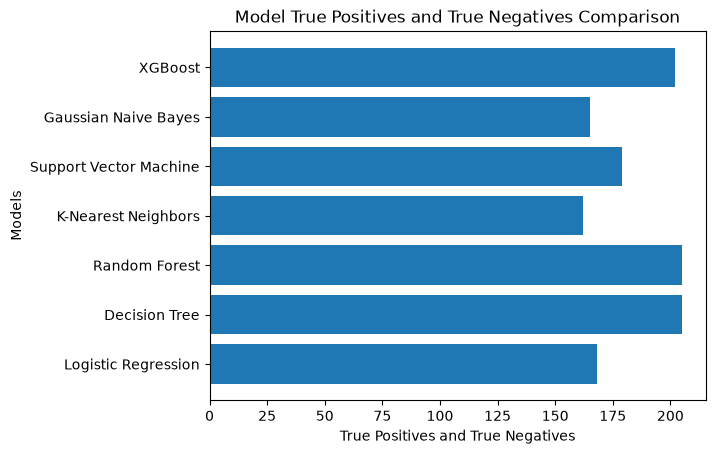

In [394]:
tpn=[skm.confusion_matrix(y_test, y_pred_logreg)[0][0]+skm.confusion_matrix(y_test, y_pred_logreg)[1][1], skm.confusion_matrix(y_test, y_pred_dt)[0][0]+skm.confusion_matrix(y_test, y_pred_dt)[1][1], skm.confusion_matrix(y_test, y_pred_rfc)[0][0]+skm.confusion_matrix(y_test, y_pred_rfc)[1][1], skm.confusion_matrix(y_test, y_pred_knn)[0][0]+skm.confusion_matrix(y_test, y_pred_knn)[1][1], skm.confusion_matrix(y_test, y_pred_svm)[0][0]+skm.confusion_matrix(y_test, y_pred_svm)[1][1], skm.confusion_matrix(y_test, y_pred_gnb)[0][0]+skm.confusion_matrix(y_test, y_pred_gnb)[1][1], skm.confusion_matrix(y_test, y_pred_xgb)[0][0]+skm.confusion_matrix(y_test, y_pred_xgb)[1][1]]
plt.barh(mdl_n, tpn)
plt.xlabel("True Positives and True Negatives")
plt.ylabel("Models")
plt.title("Model True Positives and True Negatives Comparison")
plt.show()


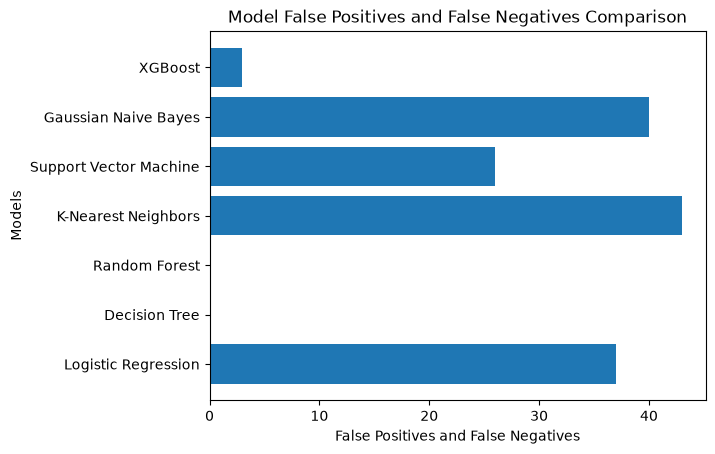

In [395]:
fpn=[skm.confusion_matrix(y_test, y_pred_logreg)[0][1]+skm.confusion_matrix(y_test, y_pred_logreg)[1][0], skm.confusion_matrix(y_test, y_pred_dt)[0][1]+skm.confusion_matrix(y_test, y_pred_dt)[1][0], skm.confusion_matrix(y_test, y_pred_rfc)[0][1]+skm.confusion_matrix(y_test, y_pred_rfc)[1][0], skm.confusion_matrix(y_test, y_pred_knn)[0][1]+skm.confusion_matrix(y_test, y_pred_knn)[1][0], skm.confusion_matrix(y_test, y_pred_svm)[0][1]+skm.confusion_matrix(y_test, y_pred_svm)[1][0], skm.confusion_matrix(y_test, y_pred_gnb)[0][1]+skm.confusion_matrix(y_test, y_pred_gnb)[1][0], skm.confusion_matrix(y_test, y_pred_xgb)[0][1]+skm.confusion_matrix(y_test, y_pred_xgb)[1][0]]
plt.barh(mdl_n, fpn)
plt.xlabel("False Positives and False Negatives")
plt.ylabel("Models")
plt.title("Model False Positives and False Negatives Comparison")
plt.show()

In [396]:
print("The ratio of True Positives and True Negatives to False Positives and False Negatives is a good indicator of the model's performance. A higher ratio indicates better performance.")

LogRegR=[skm.confusion_matrix(y_test, y_pred_logreg)[0][0]+skm.confusion_matrix(y_test, y_pred_logreg)[1][1], skm.confusion_matrix(y_test, y_pred_logreg)[0][1]+skm.confusion_matrix(y_test, y_pred_logreg)[1][0]]
print("Logistic Regression Ratio:", LogRegR[0],":", LogRegR[1])

RanForR=[skm.confusion_matrix(y_test, y_pred_rfc)[0][0]+skm.confusion_matrix(y_test, y_pred_rfc)[1][1], skm.confusion_matrix(y_test, y_pred_rfc)[0][1]+skm.confusion_matrix(y_test, y_pred_rfc)[1][0]]
print("Random Forest Ratio:", RanForR[0],":", RanForR[1])

KnnR=[skm.confusion_matrix(y_test, y_pred_knn)[0][0]+skm.confusion_matrix(y_test, y_pred_knn)[1][1], skm.confusion_matrix(y_test, y_pred_knn)[0][1]+skm.confusion_matrix(y_test, y_pred_knn)[1][0]]
print("K-Nearest Neighbors Ratio:", KnnR[0],":", KnnR[1])

SvmR=[skm.confusion_matrix(y_test, y_pred_svm)[0][0]+skm.confusion_matrix(y_test, y_pred_svm)[1][1], skm.confusion_matrix(y_test, y_pred_svm)[0][1]+skm.confusion_matrix(y_test, y_pred_svm)[1][0]]
print("SVM Ratio:", SvmR[0],":", SvmR[1])

gnbR=[skm.confusion_matrix(y_test, y_pred_gnb)[0][0]+skm.confusion_matrix(y_test, y_pred_gnb)[1][1], skm.confusion_matrix(y_test, y_pred_gnb)[0][1]+skm.confusion_matrix(y_test, y_pred_gnb)[1][0]]
print("Gaussian Naive Bayes Ratio:", gnbR[0],":", gnbR[1])

xgbR=[skm.confusion_matrix(y_test, y_pred_xgb)[0][0]+skm.confusion_matrix(y_test, y_pred_xgb)[1][1], skm.confusion_matrix(y_test, y_pred_xgb)[0][1]+skm.confusion_matrix(y_test, y_pred_xgb)[1][0]]
print("XGBoost Ratio:", xgbR[0],":", xgbR[1])

DectreR=[skm.confusion_matrix(y_test, y_pred_dt)[0][0]+skm.confusion_matrix(y_test, y_pred_dt)[1][1], skm.confusion_matrix(y_test, y_pred_dt)[0][1]+skm.confusion_matrix(y_test, y_pred_dt)[1][0]]
print("Decision Tree Ratio:", DectreR[0],":", DectreR[1])



The ratio of True Positives and True Negatives to False Positives and False Negatives is a good indicator of the model's performance. A higher ratio indicates better performance.
Logistic Regression Ratio: 168 : 37
Random Forest Ratio: 205 : 0
K-Nearest Neighbors Ratio: 162 : 43
SVM Ratio: 179 : 26
Gaussian Naive Bayes Ratio: 165 : 40
XGBoost Ratio: 202 : 3
Decision Tree Ratio: 205 : 0


**Step 8**: Select the best performing model

In [397]:
print("to pick the best model, we will use the ratio of True Positives and True Negatives to False Positives and False Negatives. The model with the highest ratio will be considered the best model.")
print("Since the ratio of Decision Tree and Random Forest is the highest, we will consider both of them as the best models for this dataset.")

to pick the best model, we will use the ratio of True Positives and True Negatives to False Positives and False Negatives. The model with the highest ratio will be considered the best model.
Since the ratio of Decision Tree and Random Forest is the highest, we will consider both of them as the best models for this dataset.


In [399]:
age = int(input("Enter your age: "))
sex = int(input("Enter your sex (0 for female, 1 for male): "))
cp = int(input("Enter your chest pain type\n0 is typical angina\n1 is atypical angina\n2 is non-anginal pain\n3 is asymptomatic\nEnter your choice (0-3):  "))
trestbps = int(input("Enter your resting blood pressure:"))
chol = int(input("Enter your cholesterol level:\nin mg/dl\nEnter your choice: "))
fbs = int(input("Enter your fasting blood sugar (0 for <120 mg/dl, 1 for >=120 mg/dl): "))
restecg = int(input("Enter your resting electrocardiographic results\n0 is normal\n1 is having ST-T wave abnormality\n2 is showing probable or definite left ventricular hypertrophy\nEnter your choice (0-2): "))
thalach = int(input("Enter your maximum heart rate achieved\nin bpm\nEnter your choice: "))
exang = int(input("Enter whether you have exercise-induced angina (0 for no, 1 for yes): "))
oldpeak = float(input("Enter your ST depression induced by exercise relative to rest\nin mm\nEnter your choice: "))
slope = int(input("Enter the slope of the peak exercise ST segment (0-2)\n0 is upsloping\n1 is flat\n2 is downsloping\nEnter your choice (0-2): "))
ca = int(input("Enter the number of major vessels (0-3) colored by fluoroscopy\n0 is 0 vessels\n1 is 1 vessel\n2 is 2 vessels\n3 is 3 vessels\nEnter your choice (0-3): "))
thal = int(input("Enter your thalassemia type (3 for normal, 6 for fixed defect, 7 for reversible defect)"))

# 1. Map inputs to original raw dataframe structure
raw_input = pd.DataFrame([{
    'age': age, 'sex': sex, 'cp': cp, 'trestbps': trestbps, 'chol': chol,
    'fbs': fbs, 'restecg': restecg, 'thalach': thalach, 'exang': exang,
    'oldpeak': oldpeak, 'slope': slope, 'ca': ca, 'thal': thal
}])

# 2. Convert to dummies
featuress = pd.get_dummies(raw_input, columns=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'], drop_first=True, dtype=int)

# 3. Align features with training data structure (Creates missing columns filled with 0)
featuress = featuress.reindex(columns=X_train.columns, fill_value=0)

# 4. Predict
prediction = dt.predict(featuress)

if prediction[0] == 1:
    print("\nResult: The model predicts a high risk of Heart Disease.")
else:
    print("\nResult: The model predicts no signs of Heart Disease.")
print(f"for a person with an age of {featuress['age'].values[0]}, sex of {sex}, chest pain type of {cp}, resting blood pressure of {trestbps}, cholesterol level of {chol}, fasting blood sugar of {fbs}, resting electrocardiographic results of {restecg}, maximum heart rate achieved of {thalach}, exercise-induced angina of {exang}, ST depression induced by exercise relative to rest of {oldpeak}, slope of the peak exercise ST segment of {slope}, number of major vessels colored by fluoroscopy of {ca}, and thalassemia type of {thal}.")


Result: The model predicts a high risk of Heart Disease.
for a person with an age of 65, sex of 0, chest pain type of 0, resting blood pressure of 150, cholesterol level of 247, fasting blood sugar of 0, resting electrocardiographic results of 1, maximum heart rate achieved of 240, exercise-induced angina of 1, ST depression induced by exercise relative to rest of 17.0, slope of the peak exercise ST segment of 2, number of major vessels colored by fluoroscopy of 3, and thalassemia type of 3.
